# Sanity Check (YOLO Model)

This notebook contains a quick sanity check to ensure the model is able to train as expected using the implementation. It is using a very small subset of the dataset to run and identify issues quickly.

In [1]:
import sys

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import detect
import dataset

In [3]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(detect)
importlib.reload(dataset);

We start by training the YOLO model with the custom keypoints head on a very small subset of the complete dataset. 

In [4]:
model = detect.CustomHeadedYolo(path="../nets")

# Train the model for some epochs in the dummy dataset.
detect.train_epochs_in(100, None, None, model, testing=True)

epoch 0; train: loss 26.60919761657715; val: loss 29.169246673583984
epoch 1; train: loss 24.71280288696289; val: loss 28.201648712158203
epoch 2; train: loss 22.611488342285156; val: loss 27.182525634765625
epoch 3; train: loss 20.739255905151367; val: loss 26.201461791992188
epoch 4; train: loss 19.354211807250977; val: loss 25.33675765991211
epoch 5; train: loss 18.17269229888916; val: loss 24.850875854492188
epoch 6; train: loss 17.24775505065918; val: loss 24.435344696044922
epoch 7; train: loss 16.262880325317383; val: loss 24.051532745361328
epoch 8; train: loss 15.477409362792969; val: loss 24.28809356689453
epoch 9; train: loss 14.825968742370605; val: loss 23.89749526977539
epoch 10; train: loss 14.094292640686035; val: loss 23.303380966186523
epoch 11; train: loss 13.303232192993164; val: loss 23.73311424255371
epoch 12; train: loss 13.001069068908691; val: loss 23.569988250732422
epoch 13; train: loss 12.748274803161621; val: loss 23.1967830657959
epoch 14; train: loss 12.3

As can be seen above, the basic implementation of the training loop works, decreasing the loss significantly over the epochs. Obviously this is just on a very small subset of the data so we expect significant overfitting to take place here. Below we look at some examples of applying the learned detector on some example images.

In [5]:
# Load one example sample from the dataset.
data = dataset.YoloDataset("../data/yolo/train")

In [8]:
img, ann = data[128]
with torch.inference_mode():
    # Try to run the learned detector on the sample.
    detector = detect.CustomPoseDetector(model)
    mean, cov = detector.detect_simple(img.unsqueeze(0).to("cuda"))[0]
    # Try also to use the baseline YOLO model.
    detector2 = detect.PoseDetector(path="../nets", compile=False)
    mean2, cov2 = detector2.detect_simple(img.unsqueeze(0))[0]

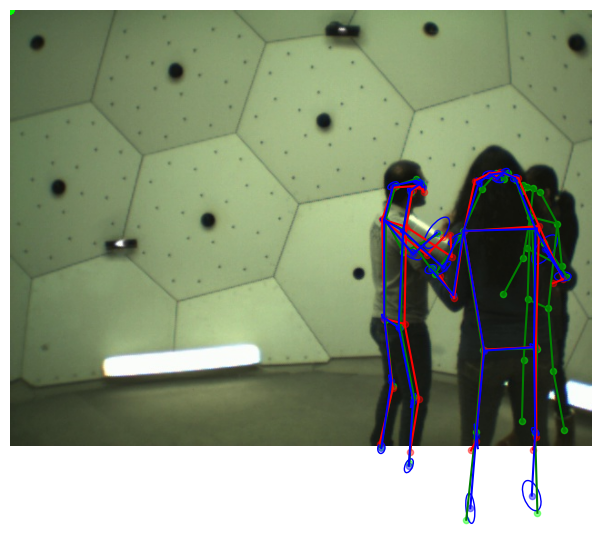

In [9]:
def draw_confidence_ellipse(mean_x, mean_y, cov, ax, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(np.maximum(0, vals))
    ellipse = Ellipse(
        xy=(mean_x, mean_y), width=width, height=height,
        angle=theta, facecolor="none", edgecolor="blue")
    return ax.add_patch(ellipse)


# Visualize the results.
fig, ax = plt.subplots(figsize=(8, 7))
for kp in ann:
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='green')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#00ff0070')
for kp in mean2.cpu().view(-1, 17, 2):
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#ff000070')
for kp, cv in zip(mean.cpu().view(-1, 17, 2), util.per_point_cov(cov.cpu(), 2)):
    for i, j in util.SKELETON:
        ax.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='blue')
    for k in range(17):
        ax.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
        draw_confidence_ellipse(kp[k, 0], kp[k, 1], cv[k].numpy(), ax)
plt.imshow(img.permute(1, 2, 0))
plt.ylim(600, 0)
plt.autoscale()
plt.axis("off")
plt.show()

As can be seen above, the predictions are not perfect, but they are also not terrible. Note that the red one is the native YOLO prediction, the blue one is the custom heads predictions, and the green skeletons are the ground truth.